PART 3: CHURN PREDICTION MODEL

Dataset shape: (2400, 29)
Columns: ['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d']...

Target Distribution:
churn_next_60d
0    1273
1    1127
Name: count, dtype: int64
Churn rate: 47.0%

Total features available: 25

DATA PREPARATION

Missing values per feature:
loyalty_tier    1386
dtype: int64

Categorical features to encode: ['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent']

Data Split:
  Training: 1728 samples (72.0%)
  Validation: 336 samples (14.0%)
  Test: 336 samples (14.0%)

✅ Features scaled successfully.

TRAINING MODELS

Training Logistic Regression...
  ✅ Accuracy: 0.8274
  ✅ AUC-ROC: 0.8849
  ✅ Precision: 0.8156
  ✅ Recall: 0.7823
  ✅ F1-Score: 0.7986

Training Random Forest...
  ✅ Accuracy: 0.7946
  ✅ AUC-ROC: 0.8694
  ✅ Precision: 0.7868
  ✅ Recall: 0.727

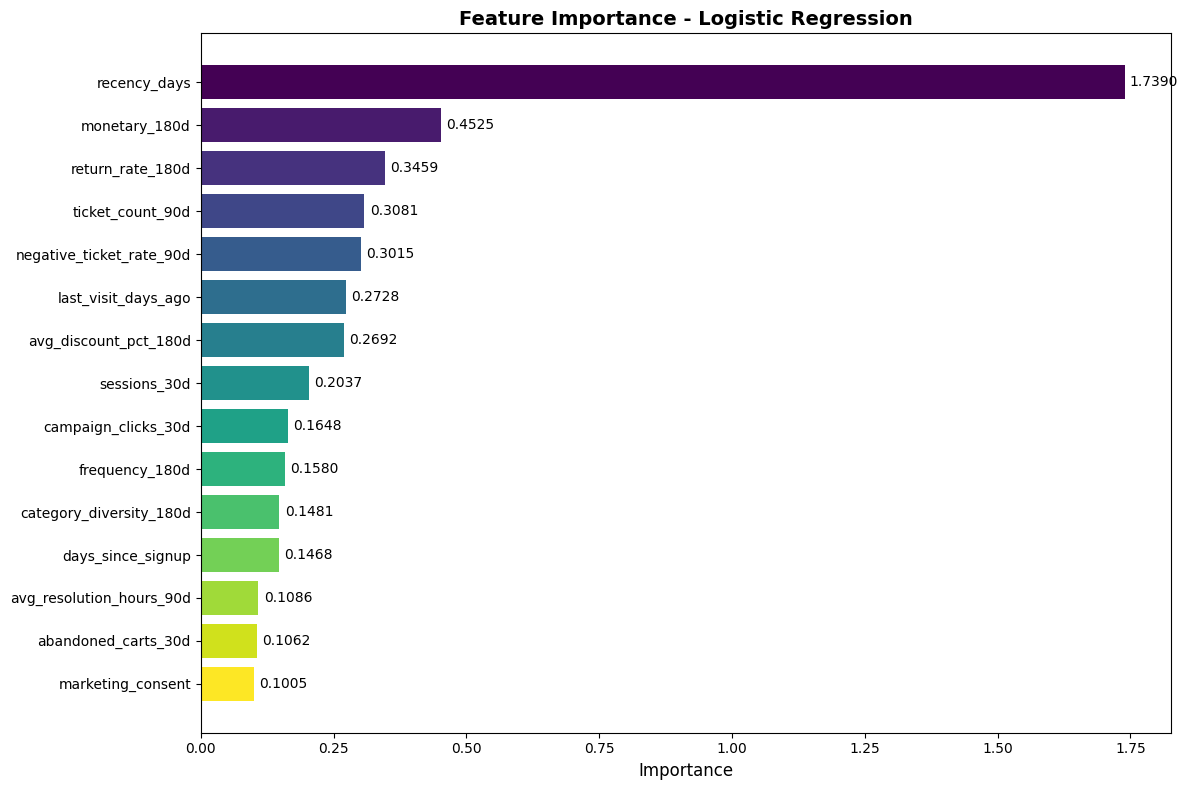


FINAL EVALUATION ON TEST SET

Logistic Regression - Test Set Performance:
  Accuracy: 0.8065
  AUC-ROC: 0.8848
  Precision: 0.8047
  Recall: 0.8095
  F1-Score: 0.8071

Classification Report:
              precision    recall  f1-score   support

    Retained       0.81      0.80      0.81       168
     Churned       0.80      0.81      0.81       168

    accuracy                           0.81       336
   macro avg       0.81      0.81      0.81       336
weighted avg       0.81      0.81      0.81       336



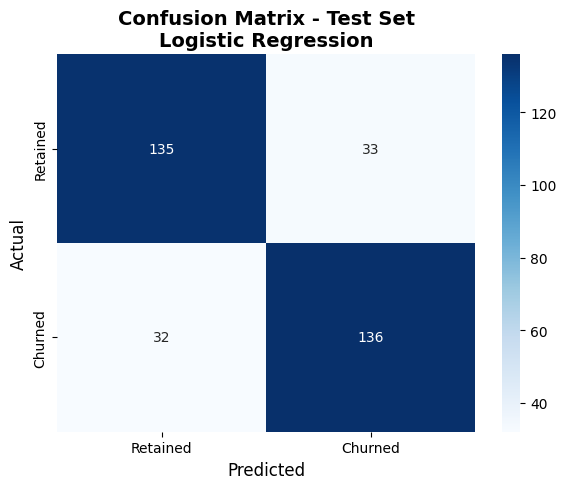


✅ Model saved to 'churn_model.pkl'
✅ Feature importance saved to 'feature_importance.csv'

✅ PART 3 COMPLETED SUCCESSFULLY


In [ ]:
# ===================================================================
# PART 3: CHURN PREDICTION MODEL - COMPLETE WORKING CODE
# (No XGBoost Required)
# ===================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ===================================================================
# SKLEARN IMPORTS (All Standard)
# ===================================================================

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.impute import SimpleImputer

print("="*60)
print("PART 3: CHURN PREDICTION MODEL")
print("="*60)

# ===================================================================
# STEP 1: LOAD DATA
# ===================================================================

# Load the pre-built RFM snapshot (safe from leakage)
df = pd.read_csv("data/rfm_modeling_snapshot.csv")

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]}...")

# Check target distribution
print("\nTarget Distribution:")
print(df['churn_next_60d'].value_counts())
print(f"Churn rate: {df['churn_next_60d'].mean()*100:.1f}%")

# ===================================================================
# STEP 2: FEATURE ENGINEERING
# ===================================================================

# Identify feature columns
exclude_cols = ['customer_id', 'snapshot_date', 'churn_next_60d', 'split']
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f"\nTotal features available: {len(feature_cols)}")

# ===================================================================
# STEP 3: HANDLE MISSING VALUES
# ===================================================================

print("\n" + "="*60)
print("DATA PREPARATION")
print("="*60)

# Check missing values
missing_values = df[feature_cols].isnull().sum()
missing_values = missing_values[missing_values > 0]

if len(missing_values) > 0:
    print("\nMissing values per feature:")
    print(missing_values)
else:
    print("\n✅ No missing values found in features.")

# Handle missing values
for col in feature_cols:
    if df[col].isna().any():
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown', inplace=True)

# ===================================================================
# STEP 4: ENCODE CATEGORICAL VARIABLES
# ===================================================================

categorical_cols = df[feature_cols].select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols) > 0:
    print(f"\nCategorical features to encode: {categorical_cols}")
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
else:
    print("\n✅ No categorical features to encode.")

# ===================================================================
# STEP 5: PREPARE TRAIN/TEST SPLIT
# ===================================================================

# Split using provided column
train_idx = df['split'] == 'train'
val_idx = df['split'] == 'validation'
test_idx = df['split'] == 'test'

X = df[feature_cols]
y = df['churn_next_60d']

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"\nData Split:")
print(f"  Training: {len(X_train)} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Validation: {len(X_val)} samples ({len(X_val)/len(df)*100:.1f}%)")
print(f"  Test: {len(X_test)} samples ({len(X_test)/len(df)*100:.1f}%)")

# ===================================================================
# STEP 6: SCALE FEATURES
# ===================================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Features scaled successfully.")

# ===================================================================
# STEP 7: TRAIN MODELS (No XGBoost)
# ===================================================================

print("\n" + "="*60)
print("TRAINING MODELS")
print("="*60)

# Define models (All using scikit-learn only)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train model
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)
        y_proba = model.predict_proba(X_val_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'auc': auc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    
    print(f"  ✅ Accuracy: {accuracy:.4f}")
    print(f"  ✅ AUC-ROC: {auc:.4f}")
    print(f"  ✅ Precision: {precision:.4f}")
    print(f"  ✅ Recall: {recall:.4f}")
    print(f"  ✅ F1-Score: {f1:.4f}")

# ===================================================================
# STEP 8: MODEL COMPARISON
# ===================================================================

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'AUC-ROC': [results[m]['auc'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1'] for m in results]
})

print(comparison_df.to_string(index=False))

# Identify best model
best_model_name = comparison_df.loc[comparison_df['AUC-ROC'].idxmax(), 'Model']
best_model = results[best_model_name]['model']

print(f"\n✅ BEST MODEL: {best_model_name} (AUC-ROC: {comparison_df['AUC-ROC'].max():.4f})")

# ===================================================================
# STEP 9: FEATURE IMPORTANCE
# ===================================================================

print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importance
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    importance = best_model.feature_importances_
elif best_model_name == 'Logistic Regression':
    importance = np.abs(best_model.coef_[0])
else:
    importance = np.ones(len(feature_cols)) / len(feature_cols)

# Create importance DataFrame
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': importance
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
for i, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# ===================================================================
# STEP 10: VISUALIZE FEATURE IMPORTANCE
# ===================================================================

fig, ax = plt.subplots(figsize=(12, 8))
top_features = feature_importance.head(15)
colors_imp = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
bars = ax.barh(range(len(top_features)), top_features['importance'].values, color=colors_imp)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
ax.invert_yaxis()
for bar, imp in zip(bars, top_features['importance'].values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{imp:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ===================================================================
# STEP 11: TEST SET EVALUATION
# ===================================================================

print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

# Evaluate best model on test set
if best_model_name == 'Logistic Regression':
    y_test_pred = best_model.predict(X_test_scaled)
    y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_test_pred = best_model.predict(X_test)
    y_test_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"\n{best_model_name} - Test Set Performance:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  AUC-ROC: {test_auc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Retained', 'Churned']))

# ===================================================================
# STEP 12: CONFUSION MATRIX
# ===================================================================

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix - Test Set\n{best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ===================================================================
# STEP 13: SAVE MODEL
# ===================================================================

import pickle

# Save model and associated data
model_data = {
    'model': best_model,
    'scaler': scaler if best_model_name == 'Logistic Regression' else None,
    'feature_columns': feature_cols,
    'model_name': best_model_name,
    'performance': {
        'test_accuracy': test_accuracy,
        'test_auc': test_auc,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1
    },
    'feature_importance': feature_importance.to_dict('records')
}

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("\n✅ Model saved to 'churn_model.pkl'")

# Save feature importance
feature_importance.to_csv('feature_importance.csv', index=False)
print("✅ Feature importance saved to 'feature_importance.csv'")

print("\n" + "="*60)
print("✅ PART 3 COMPLETED SUCCESSFULLY")
print("="*60)